<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [3]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 144.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 151.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 150.5 MB/s eta 0:00:00


### Step 2: Load the Dataset


In [16]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


In [17]:
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
# Drop NaNs created by non-numeric text to prevent binning errors
df_plot = df.dropna(subset=['ConvertedCompYearly'])

Text(0, 0.5, 'Frequency')

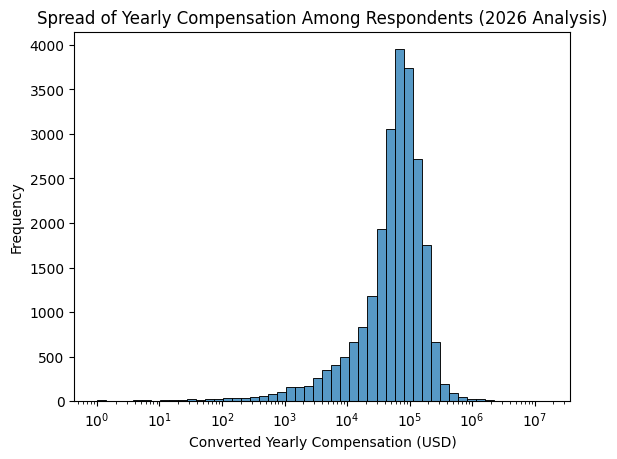

In [18]:
# Option B: Use a log scale for the x-axis
sns.histplot(df['ConvertedCompYearly'], bins=50, log_scale=True)
# Add descriptive labels
plt.title('Spread of Yearly Compensation Among Respondents (2026 Analysis)')
plt.xlabel('Converted Yearly Compensation (USD)')
plt.ylabel('Frequency')

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [19]:
## Write your code here
# 1. Filter for full-time employed respondents
full_time_df = df[df['Employment'] == 'Employed, full-time']

In [22]:
# 2. Calculate the median yearly compensation for this group
median_comp = full_time_df['ConvertedCompYearly'].median()

In [23]:
print(f"Median Compensation for Full-Time Employed Respondents: ${median_comp:,.2f}")

Median Compensation for Full-Time Employed Respondents: $69,814.00


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



In [24]:
## Write your code here
df['Country'].isnull().sum()

np.int64(6507)

In [25]:
mode_country = df['Country'].mode()[0]
print(mode_country)

United States of America


In [26]:
df['Country'] = df['Country'].fillna(mode_country)

In [27]:
df['Country'].isnull().sum()

np.int64(0)

In [28]:
!pip install country_converter --upgrade

In [29]:
import country_converter as coco
cc = coco.CountryConverter()
# Replace any unrecognized entries with the original value from the column
df['ISO3_Country'] = cc.pandas_convert(series=df['Country'], to='ISO3', not_found='Nomadic')
# If you specifically want to fill a column with its own values where mapping failed:
#df['Country'] = cc.pandas_convert(series=df['Country'], to='name_short', not_found='update')

Nomadic not found in regex


In [30]:
df['ISO3_Country'].value_counts()

ISO3_Country
USA    17602
DEU     4947
IND     4231
GBR     3224
UKR     2672
       ...  
FSM        1
NRU        1
TCD        1
DJI        1
SLB        1
Name: count, Length: 183, dtype: int64

In [31]:
# 1. Identify the top 10 countries by number of respondents
top_countries = df['ISO3_Country'].value_counts().nlargest(10).index
df_top = df[df['ISO3_Country'].isin(top_countries)]

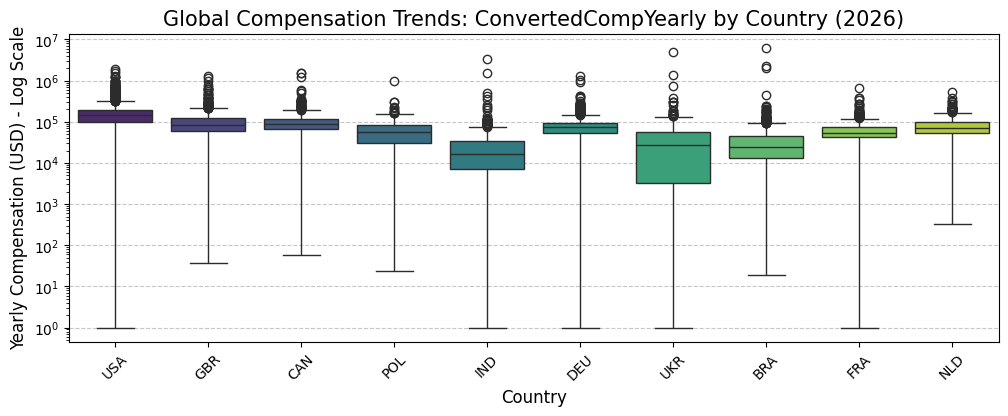

In [32]:
# 2. Create the box plot
plt.figure(figsize=(12, 4))
sns.boxplot(data=df_top, x='ISO3_Country', y='ConvertedCompYearly', hue='ISO3_Country', palette="viridis", legend=False)
# 3. Use Log Scale if outliers are extreme (common in 2026 salary data)
plt.yscale('log')
# 4. Formatting
plt.title('Global Compensation Trends: ConvertedCompYearly by Country (2026)', fontsize=15)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Yearly Compensation (USD) - Log Scale', fontsize=12)
plt.xticks(rotation=45) # Rotate names for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [33]:
## Write your code here
##Write your code here
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
# 2. Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

In [34]:
# 3. Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# 4. Identify outliers
outliers = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Number of Outliers: {len(outliers)}")

Lower Bound: -80177.25
Upper Bound: 220860.75
Number of Outliers: 978


Text(0, 0.5, 'Compensation (Log Scaled)')

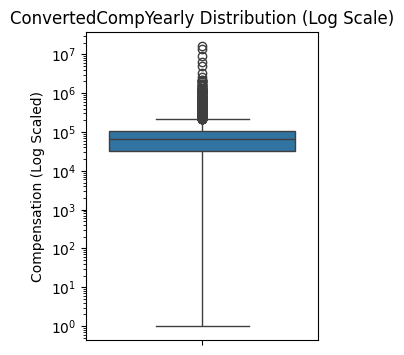

In [35]:
plt.figure(figsize=(3, 4))
sns.boxplot(y='ConvertedCompYearly', data=df)
# Apply a logarithmic scale to the Y-axis
plt.yscale('log')
plt.title('ConvertedCompYearly Distribution (Log Scale)')
plt.ylabel('Compensation (Log Scaled)')

In [36]:
# 3. Create a new DataFrame excluding outliers
# This filters for values strictly within the bounds
df_cleaned = df[(df['ConvertedCompYearly'] >= lower_bound) & 
                (df['ConvertedCompYearly'] <= upper_bound)]

In [37]:
df_cleaned.shape

(22457, 115)

In [38]:
# Verification: Compare sizes
print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_cleaned)}")
print(f"Outliers removed: {len(df) - len(df_cleaned)}")

Original rows: 65437
Cleaned rows: 22457
Outliers removed: 42980


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


In [39]:
## Write your code here
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['WorkExp'] = pd.to_numeric(df['WorkExp'], errors='coerce')
df['JobSatPoints_1'] = pd.to_numeric(df['JobSatPoints_1'], errors='coerce')

In [40]:
# 1. Calculate the correlation matrix for the specific 3 variables
# Ensure numeric_only=True to handle only quantitative columns
corr_matrix = df[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']].corr()
print(corr_matrix)

                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.154114        0.020306
WorkExp                         0.154114  1.000000       -0.026490
JobSatPoints_1                  0.020306 -0.026490        1.000000


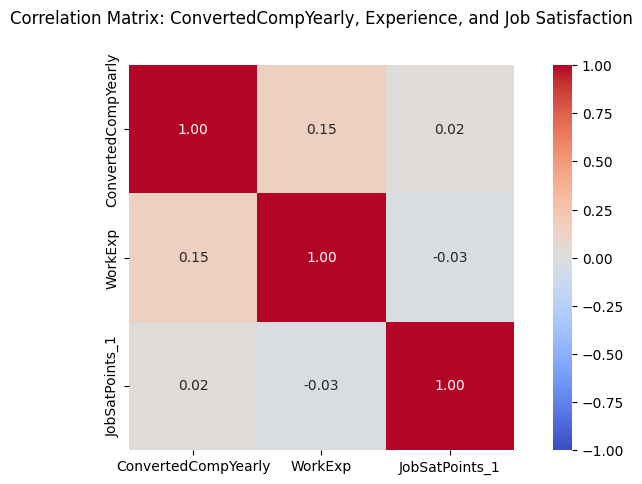

In [41]:
# 2. Plot the Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, 
            annot=True,      # Displays numerical values in each cell
            cmap='coolwarm', # Classic red-blue palette for positive/negative
            fmt=".2f",       # Rounds to 2 decimal places
            vmin=-1, vmax=1, # Sets standard correlation bounds
            center=0,        # Centers color at no correlation
            square=True)     # Forces cells to be square-shaped
plt.title('Correlation Matrix: ConvertedCompYearly, Experience, and Job Satisfaction', pad=30)
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


In [42]:
## Write your code here
# Compute correlation
correlation_ConvertedCompYearly_WorkExp = df['ConvertedCompYearly'].corr(df['WorkExp'])
correlation_ConvertedCompYearly_JobSatPoints_1 = df['ConvertedCompYearly'].corr(df['JobSatPoints_1'])

In [43]:
print(correlation_ConvertedCompYearly_WorkExp)
print(correlation_ConvertedCompYearly_JobSatPoints_1 )

0.15411426223708888
0.02030638129456558


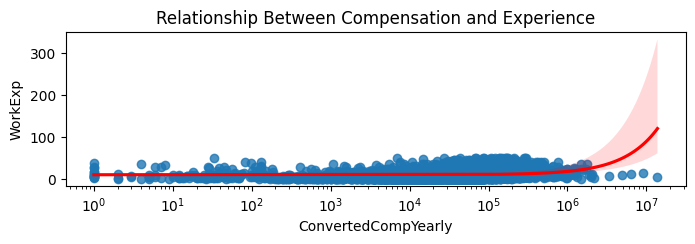

In [44]:
plt.figure(figsize=(8, 2))
sns.regplot(x='ConvertedCompYearly', y='WorkExp', data=df, line_kws={"color":"red"})
plt.xscale('log')
plt.title('Relationship Between Compensation and Experience')
plt.show()

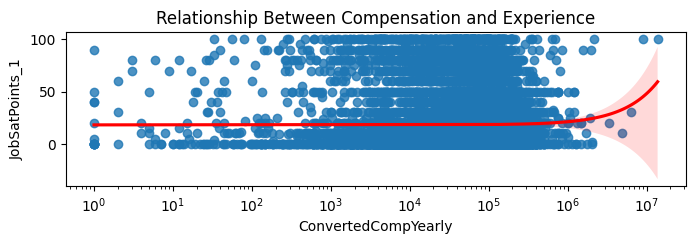

In [45]:
plt.figure(figsize=(8, 2))
sns.regplot(x='ConvertedCompYearly', y='JobSatPoints_1', data=df, line_kws={"color":"red"})
plt.xscale('log')
plt.title('Relationship Between Compensation and Experience')
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
